 # Working With Boston AirBnB Data 

In this project for my DataScience Nanodegree Program from Udacity, I decided to do an analysis on Boston AirBnB data 
from https://www.kaggle.com/airbnb/boston. I have three main questions that I want to find answers to and they are:













 1) Do AirBnb properties near Boston Logan International Airport tend to get higher ratings on location?
 
 2)  What does the difference in prices look like between the properties near the airport compared to those farther than  airport? (For this analysis, I will be focusing on only one bedroom rentals)

 3) Compare the overall review scores as we go farther from the airport
 

# Process

In order to compare the ratings of location between properties near and farther than airport, I will be using 'longitude' and 'latitude' for each property and compute the distance between that property to that of Boston Logan International Airport which is 42.366978(latitude) and 71.022362(longitude) 
Credit: https://www.latlong.net/place/logan-international-airport-bos-boston-ma-usa-1815.html 

In order to compute the distance between two points , I am using haversine formula with errors typically upto 0.3%

Haversine formula:	a = sin²(Δφ/2) + cos φ1 ⋅ cos φ2 ⋅ sin²(Δλ/2)
                    c = 2 ⋅ atan2( √a, √(1−a) )
                    d = R ⋅ c
                    where	φ is latitude, λ is longitude, R is earth’s radius (mean radius = 6,371km);
                    note that angles need to be in radians to pass to trig functions! This gives the distance in km
Credit:https://www.movable-type.co.uk/scripts/latlong.html


In [605]:
# Basic Import and Setup

import numpy as np
from math import *
import math
import pandas as pd
import re 
from re import sub
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
%matplotlib inline

listings_df = pd.read_csv('./Boston Data/listings.csv')
reviews_df = pd.read_csv('./Boston Data/reviews.csv')
listings_df.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,12147973,https://www.airbnb.com/rooms/12147973,20160906204935,2016-09-07,Sunny Bungalow in the City,"Cozy, sunny, family home. Master bedroom high...",The house has an open and cozy feel at the sam...,"Cozy, sunny, family home. Master bedroom high...",none,"Roslindale is quiet, convenient and friendly. ...",...,NaN,f,NaN,NaN,f,moderate,f,f,1,NaN
1,3075044,https://www.airbnb.com/rooms/3075044,20160906204935,2016-09-07,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,9.0,f,NaN,NaN,t,moderate,f,f,1,1.30
2,6976,https://www.airbnb.com/rooms/6976,20160906204935,2016-09-07,Mexican Folk Art Haven in Boston,"Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...",none,The LOCATION: Roslindale is a safe and diverse...,...,10.0,f,NaN,NaN,f,moderate,t,f,1,0.47
3,1436513,https://www.airbnb.com/rooms/1436513,20160906204935,2016-09-07,Spacious Sunny Bedroom Suite in Historic Home,Come experience the comforts of home away from...,Most places you find in Boston are small howev...,Come experience the comforts of home away from...,none,Roslindale is a lovely little neighborhood loc...,...,10.0,f,NaN,NaN,f,moderate,f,f,1,1.00
4,7651065,https://www.airbnb.com/rooms/7651065,20160906204935,2016-09-07,Come Home to Boston,"My comfy, clean and relaxing home is one block...","Clean, attractive, private room, one block fro...","My comfy, clean and relaxing home is one block...",none,"I love the proximity to downtown, the neighbor...",...,10.0,f,NaN,NaN,f,flexible,f,f,1,2.25


In [606]:
# Shape of our dataset
# 3585 rows and 95 columns
listings_df.shape

(3585, 95)

In [607]:
listings_df.shape

(3585, 95)

# Question 1

Do AirBnb properties near Boston Logan International Airport tend to get higher ratings on location?  

In [608]:
# Create a dataframe with only the columns needed for the calculation
new_df = listings_df[['id','latitude','longitude','review_scores_location']]
# Check if any of the values in longitude and latitude is missing
sum(new_df['longitude'].isnull()),sum(new_df['latitude'].isnull())


(0, 0)

In [609]:
# Check for missing values in 'review_scores_location'
sum(new_df['review_scores_location'].isnull())

822

In [610]:
new_df.head()

,id,latitude,longitude,review_scores_location
0,12147973,42.282619,-71.133068,NaN
1,3075044,42.286241,-71.134374,9.0
2,6976,42.292438,-71.135765,9.0
3,1436513,42.281106,-71.121021,10.0
4,7651065,42.284512,-71.136258,9.0


In [611]:
def calculate_distance(p1,p2):
    """
        Function that takes two tuples of latitude and longitude and outputs the distance in km 
        Using Haversine Formula
        
        Input: Two Tuple objects of latitude and longitude
        Output: Distance value in km
    """
    R = 6373.0
    lat1 = radians(p1[0])
    lon1 = radians(p1[1])
    lat2 = radians(p2[0])
    lon2 = radians(p2[1])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    
    return distance

In [612]:
# Data Frame after adding a distance column
new_df



,id,latitude,longitude,review_scores_location
0,12147973,42.282619,-71.133068,NaN
1,3075044,42.286241,-71.134374,9.0
2,6976,42.292438,-71.135765,9.0
3,1436513,42.281106,-71.121021,10.0
4,7651065,42.284512,-71.136258,9.0
...,...,...,...,...
3580,8373729,42.380968,-71.083795,8.0
3581,14844274,42.347503,-71.118336,NaN
3582,14585486,42.371771,-71.071300,NaN
3583,14603878,42.385226,-71.080923,8.0


In [613]:
def add_distance_column(df):
    """
        Function that adds computed values(distance of a property from airport) in 'distance' column
        
        Input: Takes in a dataframe object as input
        Output: Returns a new dataframe object with new 'distance' column
    """
    df['distance'] = 0
    for i in range(len(df)):
        p1 = (df.loc[i,'latitude'] , df.loc[i,'longitude'])
        p2 = (42.366978,-71.022362)
        df.loc[i,'distance'] = calculate_distance(p1,p2) / 1.609344
    return df

# Apply the function on new_df
new_df = add_distance_column(new_df)



<ipython-input-613-7acb7e60985f>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['distance'] = 0
/Users/sujanshahi/anaconda3/lib/python3.8/site-packages/pandas/core/indexing.py:1765: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(loc, value)


In [614]:
new_df

,id,latitude,longitude,review_scores_location,distance
0,12147973,42.282619,-71.133068,NaN,8.123816
1,3075044,42.286241,-71.134374,9.0,7.993593
2,6976,42.292438,-71.135765,9.0,7.753480
3,1436513,42.281106,-71.121021,10.0,7.787248
4,7651065,42.284512,-71.136258,9.0,8.146005
...,...,...,...,...,...
3580,8373729,42.380968,-71.083795,8.0,3.282376
3581,14844274,42.347503,-71.118336,NaN,5.083112
3582,14585486,42.371771,-71.071300,NaN,2.520788
3583,14603878,42.385226,-71.080923,8.0,3.245099


In [615]:
# Check for the correlation and as we can see that there is a negative correlation between 'review_scores_location' and 'distance'
corrM = new_df.corr()
corrM['review_scores_location'].sort_values(ascending=False)

review_scores_location    1.000000
latitude                  0.229395
id                        0.044997
longitude                 0.038539
distance                 -0.186709
Name: review_scores_location, dtype: float64

In [616]:
# Counting the number of missing values in 'review_scores_location'
sum(new_df['review_scores_location'].isnull())

822

In [617]:
#Filling the missing values with mean in 'review_scores_location' column
new_df['review_scores_location'].fillna(value=math.floor(new_df['review_scores_location'].mean()),inplace=True)

/Users/sujanshahi/anaconda3/lib/python3.8/site-packages/pandas/core/series.py:4517: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(


In [618]:
new_df

,id,latitude,longitude,review_scores_location,distance
0,12147973,42.282619,-71.133068,9.0,8.123816
1,3075044,42.286241,-71.134374,9.0,7.993593
2,6976,42.292438,-71.135765,9.0,7.753480
3,1436513,42.281106,-71.121021,10.0,7.787248
4,7651065,42.284512,-71.136258,9.0,8.146005
...,...,...,...,...,...
3580,8373729,42.380968,-71.083795,8.0,3.282376
3581,14844274,42.347503,-71.118336,9.0,5.083112
3582,14585486,42.371771,-71.071300,9.0,2.520788
3583,14603878,42.385226,-71.080923,8.0,3.245099


<AxesSubplot:xlabel='distance', ylabel='review_scores_location'>

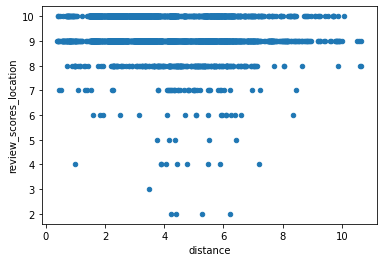

In [619]:
new_df.plot(kind="scatter",y="review_scores_location",x="distance")

In [620]:
def count_ratings(df,rating_column):
    """
        Function to count the number of ratings within distances like '0-4','4-8','8-12'
        
        Input: Takes in a dataframe object and a column name
        Ouptue: Returns a dictionary object with distances e.g. '0-4' as key and dictionary of ratings with their counts
    
    """
    ratings = {'0-4':{},'4-8':{},'8-12':{}}
    for i in range(len(df)):
        rating = df.loc[i,rating_column]
        d = df.loc[i,'distance']
        if d > 0 and d < 4:
            if rating in ratings['0-4']:
                ratings['0-4'][rating] += 1
            else:
                ratings['0-4'][rating] = 1
        elif d > 4 and d < 8:
            if rating in ratings['4-8']:
                ratings['4-8'][rating] += 1
            else:
                ratings['4-8'][rating] = 1
        else:
            if rating in ratings['8-12']:
                ratings['8-12'][rating] +=1
            else:
                ratings['8-12'][rating] = 1
                
        
    return ratings

In [626]:
ratings_dict = count_ratings(new_df,'review_scores_location')
ratings_dict

{'0-4': {10.0: 1130,
  9.0: 821,
  8.0: 80,
  7.0: 10,
  4.0: 3,
  3.0: 1,
  6.0: 5,
  5.0: 1},
 '4-8': {9.0: 767,
  10.0: 458,
  8.0: 151,
  2.0: 4,
  7.0: 32,
  6.0: 12,
  5.0: 4,
  4.0: 6},
 '8-12': {9.0: 60, 10.0: 32, 7.0: 1, 8.0: 6, 6.0: 1}}

In [627]:
def delete_ratings_smaller_than_5(d):
    """Special Function to delete any ratings smaller than 5.
    
        Input: Dictionary Object with '0-4', '4-8' and '8-12' as keys and dictionaries of ratings as values
        Output: Deletes any ratings less than 5.
    
    """
    for i in range(5):
        if i in d['0-4']:
            del d['0-4'][i]
        if i in d['4-8']:
            del d['4-8'][i]
        if i in d['8-12']:
            del d['8-12'][i]
        
delete_ratings_smaller_than_5(ratings_dict)

In [635]:
ratings_dict

{'0-4': {10.0: 1130, 9.0: 821, 8.0: 80, 7.0: 10, 6.0: 5, 5.0: 1},
 '4-8': {9.0: 767, 10.0: 458, 8.0: 151, 7.0: 32, 6.0: 12, 5.0: 4},
 '8-12': {9.0: 60, 10.0: 32, 7.0: 1, 8.0: 6, 6.0: 1}}

In [638]:
def convert_dict_to_dataframe(d):
    """
        Special Function that converts a dictionary to a dataframe object
        INPUT: Dictionary object
        Output: Dataframe object
    
    """
    distance = []
    ten = []
    nine = []
    eight = []
    seven = []
    six = []
    five = [] 
    for key in d:
        distance.append(key)
        ten.append(d[key][10]) if 10 in d[key] else ten.append(0)
        nine.append(d[key][9]) if 9 in d[key] else nine.append(0)
        eight.append(d[key][8]) if 8 in d[key] else eight.append(0)
        seven.append(d[key][7]) if 7 in d[key] else seven.append(0)
        six.append(d[key][6])  if 6 in d[key] else six.append(0)
        five.append(d[key][5]) if 5 in d[key] else five.append(0)
    
    temp_dict = {'distance':distance, '10':ten, '9': nine, '8': eight,'7':seven,'6':six,'5':five}
    ratings_df = pd.DataFrame(temp_dict)
    
    return ratings_df

ratings_df = convert_dict_to_dataframe(ratings_dict)
ratings_df

,distance,10,9,8,7,6,5
0,0-4,1130,821,80,10,5,1
1,4-8,458,767,151,32,12,4
2,8-12,32,60,6,1,1,0


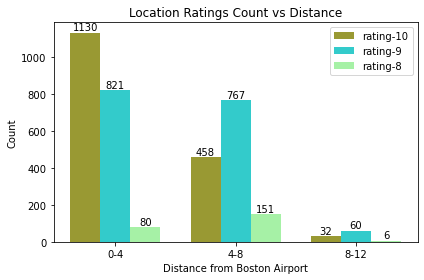

In [661]:
def create_bar_chart_for_distance_vs_ratings(df,xLabel,yLabel,title,saveAs):
    """
        Special Function to create a distance vs ratings bar chart.
        
        Input: df, dataframe object
               xLabel: Label for horizontal axis
               yLabel: Label for vertical axis
               tile: Title for the bar chart
               saveAs: Name and extension for the file to be saved as
        
        Output: Prints a barchart and saves the figure to a local machine
    
    """
    
    
    """
        Helper Function
    
    """
    # Code Credit: https://matplotlib.org/3.3.3/gallery/lines_bars_and_markers/barchart.html#sphx-glr-gallery-lines-bars-and-markers-barchart-py
    def autolabel(rects):
        """
            Function to display counts on top of each bar in a bar chart.
        """
        """Attach a text label above each bar in *rects*, displaying its height."""
        for rect in rects:
            height = rect.get_height()
            ax.annotate('{}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0,0.15), # .25 vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')
    n_groups = 3

    fig, ax = plt.subplots()
    index = np.arange(n_groups)
    bar_width = 0.25
    opacity = 0.8

    bar_10 = plt.bar(index,ratings_df['10'],bar_width,
                    alpha=opacity,
                    color='olive',
                    label='rating-10')

    bar_9 = plt.bar(index+bar_width,ratings_df['9'],bar_width,
                    alpha=opacity,
                    color='c',
                    label='rating-9')
    bar_8 = plt.bar(index+2*bar_width, ratings_df['8'],bar_width,
                    alpha=opacity,
                    color='lightgreen',
                    label='rating-8')


    plt.xlabel(xLabel)
    plt.ylabel(yLabel)
    plt.title(title)
    plt.xticks((index+ bar_width),('0-4','4-8','8-12'))
    plt.legend()
    plt.savefig(saveAs)
    autolabel(bar_10)
    autolabel(bar_9)
    autolabel(bar_8)
    plt.tight_layout()
    plt.show()
            
(create_bar_chart_for_distance_vs_ratings(ratings_df,xLabel='Distance from Boston Airport',yLabel='Count',title='Location Ratings Count vs Distance',saveAs='loc-ratings-vs-distance.jpg'))

# Question 2


In [662]:
# Only Select properties with one bedroom and assign it to a new dataframe
prices_comp_df = listings_df[['id','bedrooms','latitude','longitude','price']]

In [663]:
# Cleaning the price column
def clean_price(price):
    """
        Function that converts a string with '$' prefix to an a float after removing $
        
        Input: String
        Output: Float
    """
    try:
        return float(sub(r'[^\d.]','',price))
    except:
        return float(price)
prices_comp_df['price'] = prices_comp_df['price'].map(clean_price)

<ipython-input-663-6a9f3b4198fd>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices_comp_df['price'] = prices_comp_df['price'].map(clean_price)


In [664]:
prices_comp_df

,id,bedrooms,latitude,longitude,price
0,12147973,2.0,42.282619,-71.133068,250.0
1,3075044,1.0,42.286241,-71.134374,65.0
2,6976,1.0,42.292438,-71.135765,65.0
3,1436513,1.0,42.281106,-71.121021,75.0
4,7651065,1.0,42.284512,-71.136258,79.0
...,...,...,...,...,...
3580,8373729,1.0,42.380968,-71.083795,69.0
3581,14844274,1.0,42.347503,-71.118336,150.0
3582,14585486,1.0,42.371771,-71.071300,198.0
3583,14603878,1.0,42.385226,-71.080923,65.0


In [665]:
def count_avg_prices(df):
    """
        Function that calculates average price of Airbnb properties within a distance of 12 miles
        
        Input: Takes in a dataframe object
        Output: Returns a dictionary with 'distance' as a key and average prices as values.
    """
    prices = {'0-4':{'num':0,'sum':0},'4-8':{'num':0,'sum':0},'8-12':{'num':0,'sum':0}}
    for i in range(len(df)):
        price = df.loc[i,'price']
        d = df.loc[i,'distance']
        if d > 0 and d < 4:
            prices['0-4']['num'] += 1
            prices['0-4']['sum'] += price
        elif d > 4 and d < 8:
            prices['4-8']['num'] += 1
            prices['4-8']['sum'] += price 
        else:
            prices['8-12']['num'] += 1
            prices['8-12']['sum'] += price
    avg_price_dict = {'0-4':math.floor(prices['0-4']['sum']/prices['0-4']['num']),
                      '4-8':math.floor(prices['4-8']['sum']/prices['4-8']['num']),
                      '8-12':math.floor(prices['8-12']['sum']/prices['8-12']['num'])}
    return avg_price_dict

In [666]:
# Add distance column
prices_comp_df = add_distance_column(prices_comp_df)
avg_prices_dict = count_avg_prices(prices_comp_df)

<ipython-input-613-7acb7e60985f>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['distance'] = 0
/Users/sujanshahi/anaconda3/lib/python3.8/site-packages/pandas/core/indexing.py:1765: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(loc, value)


In [667]:
prices_comp_df.head()

,id,bedrooms,latitude,longitude,price,distance
0,12147973,2.0,42.282619,-71.133068,250.0,8.123816
1,3075044,1.0,42.286241,-71.134374,65.0,7.993593
2,6976,1.0,42.292438,-71.135765,65.0,7.753480
3,1436513,1.0,42.281106,-71.121021,75.0,7.787248
4,7651065,1.0,42.284512,-71.136258,79.0,8.146005


In [668]:
# Only select datas for one bedrooms.
one_bedroom_df = prices_comp_df[prices_comp_df['bedrooms']==1]

In [669]:
# Check for missing values and replace them with mean
sum(one_bedroom_df['bedrooms'].isnull())
one_bedroom_df['bedrooms'].fillna(one_bedroom_df['bedrooms'].mean())
one_bedroom_df

,id,bedrooms,latitude,longitude,price,distance
1,3075044,1.0,42.286241,-71.134374,65.0,7.993593
2,6976,1.0,42.292438,-71.135765,65.0,7.753480
3,1436513,1.0,42.281106,-71.121021,75.0,7.787248
4,7651065,1.0,42.284512,-71.136258,79.0,8.146005
5,12386020,1.0,42.291690,-71.131893,75.0,7.641882
...,...,...,...,...,...,...
3580,8373729,1.0,42.380968,-71.083795,69.0,3.282376
3581,14844274,1.0,42.347503,-71.118336,150.0,5.083112
3582,14585486,1.0,42.371771,-71.071300,198.0,2.520788
3583,14603878,1.0,42.385226,-71.080923,65.0,3.245099


In [670]:
avg_prices_dict

{'0-4': 205, '4-8': 134, '8-12': 98}

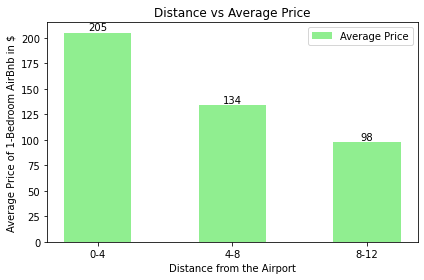

In [672]:
"""
    Creating plot
"""


def create_distance_vs_price_bar_chart_from_dict(avg_prices_dict,xLabel,yLabel,title,saveAs,label):
    """
        Function to create a distance vs price bar chart using a dictionary
    
        INPUT: avg_prices_dict, dictionary with distance as key and prices as value
               xLabel, yLabel, title, saveAs, label: String
               
        OUTPUT: Print a bar chart of distance vs price
    """
    
    
    
    """
        Helper Function
    """
    # Code Credit: https://matplotlib.org/3.3.3/gallery/lines_bars_and_markers/barchart.html#sphx-glr-gallery-lines-bars-and-markers-barchart-py
    def autolabel(rects):
        """
            Function to display counts on top of each bar in a bar chart.
        """
        """Attach a text label above each bar in *rects*, displaying its height."""
        for rect in rects:
            height = rect.get_height()
            ax.annotate('{}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0,0.15), # .25 vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')
    distance_list = []
    values_list = []
    for k, v in avg_prices_dict.items():
        distance_list.append(k)
        values_list.append(v)
    # Label locations
    x = np.arange(3)
    count = values_list
    width = 0.5
    fig,ax = plt.subplots()
    bar1 = ax.bar(x,count,width,label=label,color='lightgreen')
    ax.set_ylabel(yLabel)
    ax.set_xlabel(xLabel)
    ax.set_title(title)
    plt.xticks((index),('0-4','4-8','8-12'))
    ax.legend()
    autolabel(bar1)
    fig.tight_layout()
    plt.savefig(saveAs)
    plt.show()

create_distance_vs_price_bar_chart_from_dict(avg_prices_dict,xLabel="Distance from the Airport",yLabel="Average Price of 1-Bedroom AirBnb in $",title="Distance vs Average Price",saveAs='distance-vs-average-price.jpg',label="Average Price")
            

# Question 3


How is the overall review rating as we go farther from airport?

In [673]:
# DataFrame object to compare overall rating vs distance from the airport
overall_comp_df = listings_df[['id','property_type','latitude','longitude','review_scores_value']]

In [674]:
overall_comp_df

,id,property_type,latitude,longitude,review_scores_value
0,12147973,House,42.282619,-71.133068,NaN
1,3075044,Apartment,42.286241,-71.134374,9.0
2,6976,Apartment,42.292438,-71.135765,10.0
3,1436513,House,42.281106,-71.121021,10.0
4,7651065,House,42.284512,-71.136258,10.0
...,...,...,...,...,...
3580,8373729,Apartment,42.380968,-71.083795,9.0
3581,14844274,Apartment,42.347503,-71.118336,NaN
3582,14585486,Apartment,42.371771,-71.071300,NaN
3583,14603878,Apartment,42.385226,-71.080923,7.0


In [675]:
# Check for missing values
sum(overall_comp_df.review_scores_value.isnull())

821

In [676]:
overall_comp_df.fillna(value=math.floor(overall_comp_df['review_scores_value'].mean()),inplace=True)

/Users/sujanshahi/anaconda3/lib/python3.8/site-packages/pandas/core/frame.py:4317: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(


In [677]:
sum(overall_comp_df.review_scores_value.isnull())

0

In [679]:
# Add distance column with computed value
overall_comp_df = add_distance_column(overall_comp_df)

<ipython-input-613-7acb7e60985f>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['distance'] = 0


In [680]:
overall_comp_df

,id,property_type,latitude,longitude,review_scores_value,distance
0,12147973,House,42.282619,-71.133068,9.0,8.123816
1,3075044,Apartment,42.286241,-71.134374,9.0,7.993593
2,6976,Apartment,42.292438,-71.135765,10.0,7.753480
3,1436513,House,42.281106,-71.121021,10.0,7.787248
4,7651065,House,42.284512,-71.136258,10.0,8.146005
...,...,...,...,...,...,...
3580,8373729,Apartment,42.380968,-71.083795,9.0,3.282376
3581,14844274,Apartment,42.347503,-71.118336,9.0,5.083112
3582,14585486,Apartment,42.371771,-71.071300,9.0,2.520788
3583,14603878,Apartment,42.385226,-71.080923,7.0,3.245099


In [681]:
# Dictionary to hold dictionaries of overall ratings with distances as keys
overall_ratings_dict = count_ratings(overall_comp_df,'review_scores_value')

In [682]:
overall_ratings_dict

{'0-4': {9.0: 1130,
  10.0: 658,
  8.0: 204,
  7.0: 29,
  6.0: 26,
  4.0: 2,
  3.0: 1,
  5.0: 1},
 '4-8': {9.0: 773,
  10.0: 476,
  6.0: 22,
  8.0: 123,
  7.0: 21,
  2.0: 7,
  4.0: 10,
  5.0: 1,
  3.0: 1},
 '8-12': {9.0: 48, 10.0: 43, 8.0: 7, 7.0: 1, 6.0: 1}}

In [684]:
# Delete ratings less than 5
delete_ratings_smaller_than_5(overall_ratings_dict)

In [685]:
overall_ratings_dict

{'0-4': {9.0: 1130, 10.0: 658, 8.0: 204, 7.0: 29, 6.0: 26, 5.0: 1},
 '4-8': {9.0: 773, 10.0: 476, 6.0: 22, 8.0: 123, 7.0: 21, 5.0: 1},
 '8-12': {9.0: 48, 10.0: 43, 8.0: 7, 7.0: 1, 6.0: 1}}

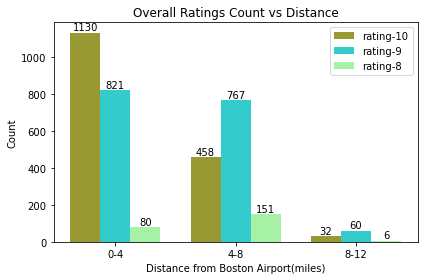

In [686]:
# Creating a bar chart
(create_bar_chart_for_distance_vs_ratings(ratings_df,xLabel='Distance from Boston Airport(miles)',yLabel='Count',title='Overall Ratings Count vs Distance',saveAs='overall-ratings-vs-distance.jpg'))